In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# TODO: 
# 1) Get LLM Concepts + Implement that 
# 2) Get LLM Labels + Implemenet Two-Stage training with that
# 3) Create Concept Completeness Baseline
# 4) Figure out the right target abstraction
# 5) Run experiments with CUB + Two-Stage Training

In [3]:
from concept_abstraction.training import train_ppo_model, evaluate_model, RandomAgent, train_two_stage_ppo_model
from concept_abstraction.selection import *
from concept_abstraction.concept_bank import *
from concept_abstraction.env_utils import *
from concept_abstraction.environments import *
from concept_abstraction.utils import *
from concept_abstraction.environments import ConceptEnv

import sys 
import argparse
import secrets
import numpy as np 
import random 
import time 
from collections import Counter
import scipy
import os
from stable_baselines3 import PPO
import pickle

In [4]:
is_jupyter = 'ipykernel' in sys.modules
is_main = __name__ == "__main__"

In [5]:
if is_main:
    if is_jupyter: 
        # Basics 
        seed        = 42
        environment_string = "mini_grid"
        training_timesteps = 100_000
        num_concepts_selected = 30
        selection_function = "policy"
        # Experiment #1 & #2
        run_basic = True
        run_iterative = False
        run_two_stage = False
        # Experiment #3
        cbm_accuracy_by_concept = None
        cbm_std_by_concept = None 
        target_abstraction = 0.05
        reward_error = 0
        # Experiment #4
        concept_source = "human_selected"
        # Experiment #5
        assess_completeness=False
        out_folder = "basic"
    else:
        parser = argparse.ArgumentParser()
        parser.add_argument('--seed', help='Random Seed', type=int, default=42)
        parser.add_argument('--environment_string', help='Which environment to create', type=str, default="tree")
        parser.add_argument('--training_timesteps', help='Number of training timesteps', type=int, default=10000)
        parser.add_argument('--num_concepts_selected', help='Number of concepts selected by greedy or random',type=int, default=0)
        parser.add_argument('--selection_function', help='When selecting, use q_value, policy, or transition?', type=str, default="policy")
        parser.add_argument('--cbm_accuracy_by_concept', help="What is the accuracy of AI per concept?", nargs='*', type=float, default=None)
        parser.add_argument('--cbm_std_by_concept', help="What is the error of AI per concept?", nargs='*', type=float, default=None)
        parser.add_argument('--run_two_stage', help='Run the basic comparisons?', action='store_true')
        parser.add_argument('--run_iterative', help='Run the basic comparisons?', action='store_true')
        parser.add_argument('--run_basic', help='Run the basic comparisons?', action='store_true')
        parser.add_argument('--target_abstraction', help='Value for the target abstraction with human performance', type=float, default=0.05)
        parser.add_argument('--reward_error', help="How much to perturb the reward by?", type=float, default=0)
        parser.add_argument('--concept_source', help='When selecting, use q_value, policy, or transition?', type=str, default="human_selected")
        parser.add_argument('--assess_completeness', help='Compare to the concept completeness algorithm?', action='store_true')
        parser.add_argument('--out_folder', help='Which folder', type=str, default="exploration")

        args = parser.parse_args()

        seed = args.seed
        environment_string = args.environment_string
        training_timesteps = args.training_timesteps 
        num_concepts_selected = args.num_concepts_selected
        selection_function = args.selection_function
        cbm_accuracy_by_concept = args.cbm_accuracy_by_concept
        cbm_std_by_concept = args.cbm_std_by_concept
        run_basic = args.run_basic
        run_iterative = args.run_iterative
        run_two_stage = args.run_two_stage
        target_abstraction = args.target_abstraction
        reward_error = args.reward_error
        concept_source = args.concept_source
        assess_completeness = args.assess_completeness
        out_folder = args.out_folder

    save_name = secrets.token_hex(4)  

In [6]:
if is_main:
        results = {}
        results['parameters'] = {'seed'      : seed,
                'environment_string'    : environment_string, 
                'training_timesteps': training_timesteps, 
                'selection_function': selection_function,
                'num_concepts_selected': num_concepts_selected,
                'cbm_accuracy_by_concept': cbm_accuracy_by_concept,
                'cbm_std_by_concept': cbm_std_by_concept,
                'target_abstraction': target_abstraction,
                'reward_error': reward_error, 
                'concept_source': concept_source,
                'assess_completeness': assess_completeness,
                'run_basic': run_basic,
                'run_iterative': run_iterative, 
                'run_two_stage': run_two_stage, 
        }
        print("Parameters {}".format(results['parameters']))

Parameters {'seed': 42, 'environment_string': 'mini_grid', 'training_timesteps': 100000, 'selection_function': 'policy', 'num_concepts_selected': 30, 'cbm_accuracy_by_concept': None, 'cbm_std_by_concept': None, 'target_abstraction': 0.05, 'reward_error': 0, 'concept_source': 'human_selected', 'assess_completeness': False, 'run_basic': True, 'run_iterative': False, 'run_two_stage': False}


In [7]:
if is_main:
    np.random.seed(seed)
    random.seed(seed)

### Basic Setup

In [8]:
obs = env.reset()[0]

NameError: name 'env' is not defined

In [20]:
direction = obs['direction']

In [22]:
agent_pos = env.agent_pos

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.agent_pos to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.agent_pos` for environment variables or `env.get_wrapper_attr('agent_pos')` that will search the reminding wrappers.
  logger.warn(


In [25]:
obs['image'].shape

(7, 7, 3)

In [28]:
infos

{'agent_position': (2, 3),
 'agent_direction': 2,
 'key_position': (1, 3),
 'door_position': (4, 5),
 'door_open': False,
 'direction_movable': {'right': True, 'down': True, 'left': False, 'up': True}}

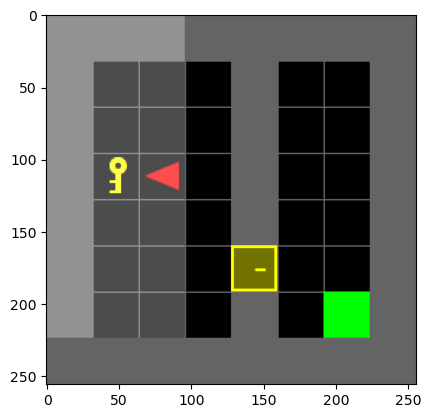

In [29]:
plt.imshow(env.render())

In [23]:
agent_pos

(2, 3)

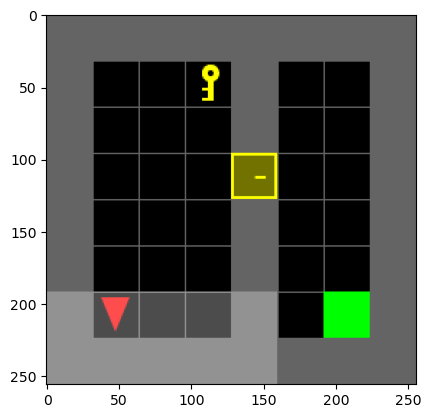

In [12]:
import matplotlib.pyplot as plt
env = gym.make("MiniGrid-DoorKey-8x8-v0",render_mode="rgb_array")
env.reset()


In [42]:
if is_main:
    concept_list = get_concepts(environment_string,concept_source,seed)
    num_concepts_selected = min(num_concepts_selected,len(concept_list))

In [43]:
if is_main:
    ground_truth_env, ground_truth_gym_env, additional_info = get_environment(environment_string, None, seed)

    if environment_string == 'mimic': 
        concept_list = additional_info['concept_list']

In [87]:
from concept_abstraction.concept_bank import get_all_mini_grid_binary_concepts

In [90]:
len(())

44

In [91]:
concept_list = get_all_mini_grid_binary_concepts()

In [70]:
env, eval_env, additional_info = get_environment("boxing",None,seed)


In [71]:
a = env.reset()

In [32]:
a = env.render()[:480//3,:480//3]

In [35]:
gray = cv2.cvtColor(a, cv2.COLOR_RGB2GRAY)

In [58]:
small_pixels = cv2.resize(gray, (84,84),interpolation=cv2.INTER_NEAREST)

array([[100, 100, 100, ..., 100, 100, 100],
       [100, 100, 100, ..., 100, 100, 100],
       [100, 100, 100, ..., 100, 100, 100],
       ...,
       [146, 146, 146, ..., 100, 100, 100],
       [146, 146, 146, ..., 100, 100, 100],
       [146, 146, 146, ..., 100, 100, 100]], dtype=uint8)

TypeError: Image data of dtype object cannot be converted to float

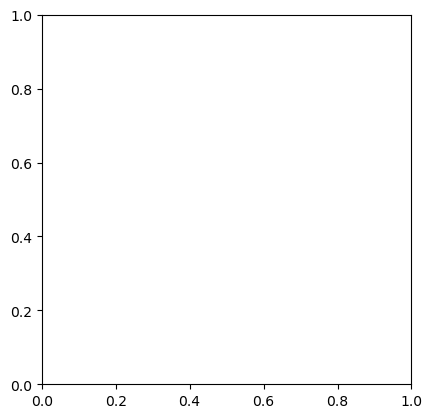

In [59]:
plt.imshow(small_pixels)

/tmp/ipykernel_3007582/995576061.py:1: RuntimeWarning: overflow encountered in multiply
  plt.imshow(small_pixels*256)


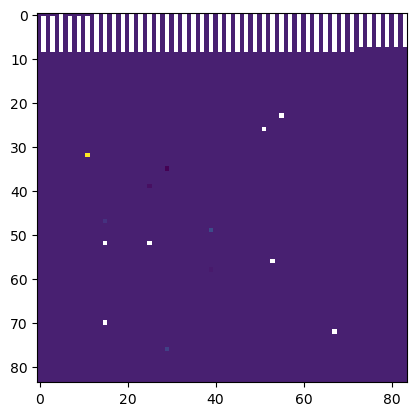

In [47]:
plt.imshow(small_pixels*256)

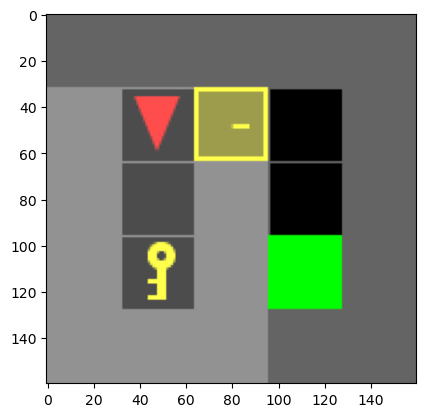

In [33]:
plt.imshow(a)

In [20]:
a = env.reset()

Pixels [[[100 100 100]
  [100 100 100]
  [100 100 100]
  ...
  [100 100 100]
  [100 100 100]
  [100 100 100]]

 [[100 100 100]
  [100 100 100]
  [100 100 100]
  ...
  [100 100 100]
  [100 100 100]
  [100 100 100]]

 [[100 100 100]
  [100 100 100]
  [100 100 100]
  ...
  [100 100 100]
  [100 100 100]
  [100 100 100]]

 ...

 [[146 146 146]
  [146 146 146]
  [146 146 146]
  ...
  [100 100 100]
  [100 100 100]
  [100 100 100]]

 [[146 146 146]
  [146 146 146]
  [146 146 146]
  ...
  [100 100 100]
  [100 100 100]
  [100 100 100]]

 [[146 146 146]
  [146 146 146]
  [146 146 146]
  ...
  [100 100 100]
  [100 100 100]
  [100 100 100]]]
Gray [[100 100 100 ... 100 100 100]
 [100 100 100 ... 100 100 100]
 [100 100 100 ... 100 100 100]
 ...
 [146 146 146 ... 100 100 100]
 [146 146 146 ... 100 100 100]
 [146 146 146 ... 100 100 100]]
Pixels [[[100 100 100]
  [100 100 100]
  [100 100 100]
  ...
  [100 100 100]
  [100 100 100]
  [100 100 100]]

 [[100 100 100]
  [100 100 100]
  [100 100 100]
  ...
 

In [18]:
a[0][0]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

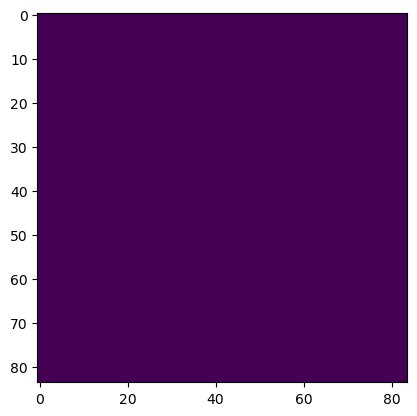

In [14]:
import matplotlib.pyplot as plt 
plt.imshow(a[0][0])

In [92]:
env, eval_env, additional_info = get_environment(environment_string,concept_list,seed)
model = train_ppo_model(env,total_timesteps=250_000,policy="MlpPolicy")

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
Training: 252500it [04:10, 1008.56it/s]                            


In [93]:
evaluate_model(environment_string,eval_env,additional_info,model,seed)

0.9221005751848808

In [ ]:
evaluate_model(environment_string,eval_env,additional_info,model,seed)

In [83]:
from concept_abstraction.environments import *
env = gym.make("MiniGrid-DoorKey-5x5-v0",render_mode="rgb_array")
env = ConceptWrapper(env,concept_list,spaces.MultiBinary(len(concept_list)),lambda env, obs: obs, obs_function=lambda env, obs, info: get_raw_state_mini_grid_2(env,info,{'observation': obs}))
env = get_recordable(env)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/gymnasium/wrappers/record_video.py:94: UserWarning: WARN: Overwriting existing videos at /usr0/home/naveenr/projects/concept_decisions/runs/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [85]:
obs, info = env.reset()
done = False
total_reward = 0.0

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = env.step(action)
    total_reward += reward
print(total_reward)
env.close()

Moviepy - Building video /usr0/home/naveenr/projects/concept_decisions/runs/videos/rl-video-episode-1.mp4.
Moviepy - Writing video /usr0/home/naveenr/projects/concept_decisions/runs/videos/rl-video-episode-1.mp4



Moviepy - Done !
Moviepy - video ready /usr0/home/naveenr/projects/concept_decisions/runs/videos/rl-video-episode-1.mp4
0.964


In [68]:
eval_env.render()

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:243: UserWarning: You tried to call render() but no `render_mode` was passed to the env constructor.
  warnings.warn("You tried to call render() but no `render_mode` was passed to the env constructor.")


In [11]:
if is_main:
    model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,training_timesteps,seed)
    
    # if os.path.exists(model_name):
    #     groundtruth_model = PPO.load(model_name)
    # else:
    # Train the groundtruth policy
    if "cyclic" in environment_string or "tree" in environment_string or "mimic" in environment_string:
        policy = "MlpPolicy"
    else:
        policy = "CnnPolicy"
    groundtruth_model = train_ppo_model(ground_truth_env,total_timesteps=1,policy=policy)
    groundtruth_model.save(model_name)
    groundtruth_reward = evaluate_model(environment_string,ground_truth_gym_env,additional_info,groundtruth_model,seed)

    results['ground_truth'] = {'reward':groundtruth_reward}
    print(results['ground_truth']['reward'])

Training: 2048it [00:03, 512.77it/s]                    


72.9916642996596


In [10]:
if is_main:
    # model_name = "../../results/models/env={}_training={}_seed={}.zip".format(environment_string,training_timesteps,seed)
    
    # if os.path.exists(model_name):
    #     groundtruth_model = PPO.load(model_name)
    # else:
    # Train the groundtruth policy
    if "cyclic" in environment_string or "tree" in environment_string or "mimic" in environment_string:
        policy = "MlpPolicy"
    else:
        policy = "CnnPolicy"
    groundtruth_model = train_ppo_model(ground_truth_env,total_timesteps=250_000,policy=policy)
    # groundtruth_model.save(model_name)
    groundtruth_reward = evaluate_model(environment_string,ground_truth_gym_env,additional_info,groundtruth_model,seed)

    results['ground_truth'] = {'reward':groundtruth_reward}
    print(results['ground_truth']['reward'])

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
Training: 100%|██████████| 250000/250000 [05:26<00:00, 764.54it/s]


91.59878762753961


### Basic Comparison

In [22]:
if is_main and run_basic:
    selection_function = "q_value"
    model_name = "../../results/q_estimates/env={}_training={}_seed={}_selection={}.pkl".format(environment_string,training_timesteps,seed,selection_function)
    results['basic_comparison'] = {}
    # if os.path.exists(model_name):
    #     q_estimates = pickle.load(open(model_name,"rb"))
    # else:
    if selection_function == "q_value":
        if environment_string == "mimic":
            q_estimates = rollout_q_estimates_td(groundtruth_model,GymnasiumWrapper(DummyVecEnv([lambda: ground_truth_gym_env])),concept_list,learning_rate=1e-3,mimic=True,total_timesteps=5000,final_training=0)
        else:
            q_estimates = rollout_q_estimates_td(groundtruth_model,ground_truth_gym_env,concept_list)
    elif selection_function == "policy":
        if environment_string == "mimic":
            q_estimates = rollout_pi_estimates(groundtruth_model,GymnasiumWrapper(DummyVecEnv([lambda: ground_truth_gym_env])),concept_list,mimic=True)
        else:
            q_estimates = rollout_pi_estimates(groundtruth_model,ground_truth_gym_env,concept_list)
    pickle.dump(q_estimates,open(model_name,"wb"))

Starting stable training for sparse rewards...
Episode 25, Avg Reward: 78.08, Loss (mean/std/max): 73.14/13.92/107.14, Epsilon: 0.099
Episode 50, Avg Reward: 98.79, Loss (mean/std/max): 81.92/15.77/108.34, Epsilon: 0.098
Episode 75, Avg Reward: 87.91, Loss (mean/std/max): 81.36/14.46/108.34, Epsilon: 0.098
Episode 100, Avg Reward: 52.44, Loss (mean/std/max): 79.68/15.28/108.34, Epsilon: 0.097
Episode 125, Avg Reward: 82.51, Loss (mean/std/max): 76.34/16.39/108.34, Epsilon: 0.097
Episode 150, Avg Reward: 77.19, Loss (mean/std/max): 71.84/19.60/108.34, Epsilon: 0.096
Episode 175, Avg Reward: 67.05, Loss (mean/std/max): 68.34/21.51/108.34, Epsilon: 0.096
Episode 200, Avg Reward: 73.14, Loss (mean/std/max): 64.33/23.32/108.34, Epsilon: 0.095
Episode 225, Avg Reward: 98.27, Loss (mean/std/max): 60.15/25.35/108.34, Epsilon: 0.095
Episode 250, Avg Reward: 75.35, Loss (mean/std/max): 55.46/26.46/108.34, Epsilon: 0.094
Episode 275, Avg Reward: 98.09, Loss (mean/std/max): 47.90/25.64/108.34, Eps

In [30]:
if is_main and run_basic:
    # Train a random policy
    if environment_string == "mimic":
        model = RandomAgent(GymnasiumWrapper(DummyVecEnv([lambda: ground_truth_gym_env])))
    else:
        model = RandomAgent(ground_truth_gym_env)
    random_reward = evaluate_model(environment_string,ground_truth_gym_env,additional_info,model,seed)
    results['basic_comparison']['random'] = {'reward':random_reward}
    print(results['basic_comparison']['random']['reward'])

57.51683114255194


In [14]:
if is_main and run_basic:
    # Train a random selector
    subset_concept, random_idx = random_selection(concept_list,num_concepts_selected)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,total_timesteps=250_000,policy="MlpPolicy")
    random_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['random_selection'] = {'reward':random_selection_reward, 'concepts': random_idx}
    print(results['basic_comparison']['random_selection']['reward'])

/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/mimic.py:140: RuntimeWarning: invalid value encountered in divide
  transitionr = np.nan_to_num(np.where(transitionr > 0, transitionr / action_counts, 0))
/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/mimic.py:141: RuntimeWarning: invalid value encountered in divide
  physpol = np.nan_to_num(action_counts / action_counts.sum(axis=1, keepdims=True))
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take 

Zeroing out 1067/2550 transitions


Training: 100%|██████████| 250000/250000 [05:13<00:00, 798.55it/s]


KeyError: 'basic_comparison'

In [26]:
if is_main and run_basic:
    # Train a greedy selector
    subset_concept, greedy_idx = greedy_selection(ground_truth_gym_env,concept_list,num_concepts_selected,selection_function,q_estimates)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,total_timesteps=250_000,policy="MlpPolicy")
    greedy_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['greedy'] = {'concepts': greedy_idx, 'reward':greedy_selection_reward}
    print(results['basic_comparison']['greedy']['reward'])


/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/mimic.py:140: RuntimeWarning: invalid value encountered in divide
  transitionr = np.nan_to_num(np.where(transitionr > 0, transitionr / action_counts, 0))
/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/mimic.py:141: RuntimeWarning: invalid value encountered in divide
  physpol = np.nan_to_num(action_counts / action_counts.sum(axis=1, keepdims=True))
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take 

Zeroing out 1071/2550 transitions


Training: 100%|██████████| 250000/250000 [05:21<00:00, 776.69it/s]


89.11200771522648


In [28]:
if is_main and run_basic:
    # Train a greedy selector
    subset_concept, greedy_idx = greedy_selection(ground_truth_gym_env,concept_list,5,selection_function,q_estimates)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,total_timesteps=250_000,policy="MlpPolicy")
    greedy_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['greedy'] = {'concepts': greedy_idx, 'reward':greedy_selection_reward}
    print(results['basic_comparison']['greedy']['reward'])


/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/mimic.py:140: RuntimeWarning: invalid value encountered in divide
  transitionr = np.nan_to_num(np.where(transitionr > 0, transitionr / action_counts, 0))
/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/mimic.py:141: RuntimeWarning: invalid value encountered in divide
  physpol = np.nan_to_num(action_counts / action_counts.sum(axis=1, keepdims=True))
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take 

Zeroing out 1152/2550 transitions


Training: 100%|██████████| 250000/250000 [05:07<00:00, 813.11it/s]


56.60550434435632


In [46]:
if is_main and run_basic:
    subset_concept, greedy_iterative_idx = greedy_iterative_selection(ground_truth_gym_env,concept_list,num_concepts_selected,groundtruth_model,selection_function,q_estimates)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,total_timesteps=training_timesteps,policy="MlpPolicy")
    greedy_iterative_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['greedy_iterative'] = {'concepts': greedy_iterative_idx, 'reward': greedy_iterative_selection_reward}
    print(results['basic_comparison']['greedy_iterative']['reward'])

/usr0/home/naveenr/.local/lib/python3.8/site-packages/sklearn/metrics/_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr0/home/naveenr/.local/lib/python3.8/site-packages/sklearn/metrics/_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr0/home/naveenr/.local/lib/python3.8/site-packages/sklearn/metrics/_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr0/home/naveenr/.local/lib/python3.8/site-packages/sklearn/metrics/_regression.py:996: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr0/home/naveenr/.local/lib/python3.8/site-packages/sklearn/metrics/_regression.py:996: UndefinedMetricWarning: R^2 score is not w

Zeroing out 14295/18800 transitions


/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/mimic.py:140: RuntimeWarning: invalid value encountered in divide
  transitionr = np.nan_to_num(np.where(transitionr > 0, transitionr / action_counts, 0))
/usr0/home/naveenr/projects/concept_decisions/concept_abstraction/mimic.py:141: RuntimeWarning: invalid value encountered in divide
  physpol = np.nan_to_num(action_counts / action_counts.sum(axis=1, keepdims=True))
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take 

49.45349338089075


In [57]:
groundtruth_model = train_ppo_model(ground_truth_env,total_timesteps=250_000,policy="MlpPolicy")
groundtruth_reward = evaluate_model(environment_string,ground_truth_gym_env,additional_info,groundtruth_model,i)
print(groundtruth_reward)

In [47]:
if is_main and run_basic:
    subset_concept, lp_idx = lp_based_selection(ground_truth_gym_env,concept_list,num_concepts_selected,selection_function,q_estimates)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,total_timesteps=training_timesteps,policy="MlpPolicy")
    lp_selection_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['basic_comparison']['lp'] = {'concepts': lp_idx, 'reward': lp_selection_reward}
    print(results['basic_comparison']['lp']['reward'])

Set parameter Username
Academic license - for non-commercial use only - expires 2025-10-14


KeyboardInterrupt: 

### Imperfect Concept Predictors

In [35]:
if is_main and (cbm_std_by_concept is not None or cbm_accuracy_by_concept is not None):
    results['inaccurate_comparison'] = {}


In [18]:
if is_main:
    greedy_inaccurate_reward = {}
    for modification in ["continuous","binary"]:
        if modification == "continuous" and cbm_std_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_continuous(func,0,std) for func,std in zip(concept_list,cbm_std_by_concept)]
        elif modification == "binary" and cbm_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary(func,acc) for func,acc in zip(concept_list,cbm_accuracy_by_concept)]
        else:
            continue 
        subset_concept = [modified_concept_predictors[i] for i in greedy_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,total_timesteps=training_timesteps,policy="MlpPolicy")
        greedy_inaccurate_reward[modification] = {
            'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
            'concepts': greedy_idx
        }

    if greedy_inaccurate_reward != {}:
        results['inaccurate_comparison']['greedy'] = greedy_inaccurate_reward
        print(greedy_inaccurate_reward)

In [19]:
if is_main:
    greedy_iterative_inaccurate_reward = {}
    for modification in ["continuous","binary"]:
        if modification == "continuous" and cbm_std_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_continuous(func,0,std) for func,std in zip(concept_list,cbm_std_by_concept)]
        elif modification == "binary" and cbm_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary(func,acc) for func,acc in zip(concept_list,cbm_accuracy_by_concept)]
        else:
            continue 
        
        subset_concept = [modified_concept_predictors[i] for i in greedy_iterative_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,total_timesteps=training_timesteps,policy="MlpPolicy")
        greedy_iterative_inaccurate_reward[modification] = {
            'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed), 
            'concepts': greedy_iterative_idx
        } 

    if greedy_iterative_inaccurate_reward != {}:
        results['inaccurate_comparison']['greedy_iterative'] = greedy_iterative_inaccurate_reward
        print(greedy_iterative_inaccurate_reward)

In [20]:
if is_main:
    lp_inaccurate_reward = {}
    for modification in ["continuous","binary"]:
        if modification == "continuous" and cbm_std_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_continuous(func,0,std) for func,std in zip(concept_list,cbm_std_by_concept)]
        elif modification == "binary" and cbm_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary(func,acc) for func,acc in zip(concept_list,cbm_accuracy_by_concept)]
        else:
            continue 
        
        subset_concept = [modified_concept_predictors[i] for i in lp_idx]
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,total_timesteps=training_timesteps,policy="MlpPolicy")
        lp_inaccurate_reward[modification] = { 'reward': evaluate_model(environment_string,eval_env,additional_info,model,seed),
        'concepts': lp_idx}

    if lp_inaccurate_reward != {}:
        results['inaccurate_comparison']['lp'] = lp_inaccurate_reward
        print(lp_inaccurate_reward)

In [21]:
if is_main:
    imperfect_lp_selection_reward = {}
    for modification in ["continuous","binary"]:
        if modification == "continuous" and cbm_std_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_continuous(func,0,std) for func,std in zip(concept_list,cbm_std_by_concept)]
        elif modification == "binary" and cbm_accuracy_by_concept is not None:
            modified_concept_predictors = [inaccurate_concepts_binary(func,acc) for func,acc in zip(concept_list,cbm_accuracy_by_concept)]
        else:
            continue 
        
        if modification == "continuous":
            subset_concept, imperfect_idx = imperfect_lp_selection(ground_truth_gym_env,modified_concept_predictors,groundtruth_model,selection_function,target_abstraction,cbm_std_by_concept,direction='min')
        else:
            subset_concept, imperfect_idx = imperfect_lp_selection(ground_truth_gym_env,modified_concept_predictors,groundtruth_model,selection_function,target_abstraction,cbm_accuracy_by_concept,direction='max')
        env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
        model = train_ppo_model(env,total_timesteps=training_timesteps,policy="MlpPolicy")
        imperfect_lp_selection_reward[modification] = evaluate_model(environment_string,eval_env,additional_info,model,seed)

    if imperfect_lp_selection_reward != {}:
        results['inaccurate_comparison']['imperfect_lp'] = imperfect_lp_selection_reward
        print(imperfect_lp_selection_reward)

### Two-Stage Concept Predictors

In [22]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    model = train_two_stage_ppo_model(environment_string,ground_truth_gym_env,concept_list,total_timesteps=training_timesteps)
    two_stage_eval = evaluate_model(environment_string,ground_truth_gym_env,additional_info,model,seed)
    per_state_loss = model.per_state_loss
    results['two_stage'] = {}

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.ale to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.ale` for environment variables or `env.get_wrapper_attr('ale')` that will search the reminding wrappers.
  logger.warn(


KeyboardInterrupt: 

In [ ]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    ground_truth_concept_env = InfoTransformWrapper(ground_truth_gym_env,[concept_list[i] for i in greedy_idx])
    ground_truth_eval_concept_env = InfoTransformWrapper(ground_truth_gym_env,[concept_list[i] for i in greedy_idx])
    model = train_two_stage_ppo_model(environment_string,ground_truth_concept_env,[concept_list[i] for i in greedy_idx],total_timesteps=training_timesteps)
    greedy_two_stage_reward = evaluate_model(environment_string,ground_truth_eval_concept_env,additional_info,model,seed)

    results['two_stage']['greedy'] = {
        'reward': greedy_two_stage_reward, 
        'concepts': greedy_idx,
    }

    print(greedy_two_stage_reward)

In [ ]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    ground_truth_concept_env = InfoTransformWrapper(ground_truth_gym_env,[concept_list[i] for i in greedy_iterative_idx])
    ground_truth_eval_concept_env = InfoTransformWrapper(ground_truth_gym_env,[concept_list[i] for i in greedy_iterative_idx])
    model = train_two_stage_ppo_model(environment_string,ground_truth_concept_env,[concept_list[i] for i in greedy_iterative_idx],total_timesteps=training_timesteps)
    greedy_iterative_two_stage_reward = evaluate_model(environment_string,ground_truth_eval_concept_env,additional_info,model,seed)

    results['two_stage']['greedy_iterative'] = {
        'reward': greedy_iterative_two_stage_reward, 
        'concepts': greedy_iterative_idx,
    }

    print(greedy_iterative_two_stage_reward)


In [ ]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_two_stage:
    ground_truth_concept_env = InfoTransformWrapper(ground_truth_gym_env,[concept_list[i] for i in lp_idx])
    ground_truth_eval_concept_env = InfoTransformWrapper(ground_truth_gym_env,[concept_list[i] for i in lp_idx])
    model = train_two_stage_ppo_model(environment_string,ground_truth_concept_env,[concept_list[i] for i in lp_idx],total_timesteps=training_timesteps)
    lp_two_stage_reward = evaluate_model(environment_string,ground_truth_eval_concept_env,additional_info,model,seed)

    results['two_stage']['lp'] = {
        'reward': lp_two_stage_reward, 
        'concepts': lp_idx,
    }

    print(lp_two_stage_reward)


In [ ]:
if is_main and run_two_stage and not isinstance(ground_truth_env, ConceptEnv) and per_state_loss is not None:
    top_k = [(idx,std) for idx,std in enumerate(per_state_loss)]
    top_k_idx = sorted(top_k,key=lambda k: k[1])[:num_concepts_selected]
    top_k_idx = [i[0] for i in top_k_idx]
    
    ground_truth_concept_env  = InfoTransformWrapper(ground_truth_gym_env,[concept_list[i] for i in top_k_idx])
    ground_truth_eval_concept_env = InfoTransformWrapper(ground_truth_gym_env,[concept_list[i] for i in top_k_idx])
    model = train_two_stage_ppo_model(environment_string,ground_truth_concept_env,[concept_list[i] for i in top_k_idx],total_timesteps=training_timesteps)
    top_k_two_stage_reward = evaluate_model(environment_string,ground_truth_eval_concept_env,additional_info,model,seed)

    results['two_stage']['top_k'] = {
        'reward': top_k_two_stage_reward, 
        'concepts': top_k_idx,
    }
    print(top_k_two_stage_reward)


### Iterative

In [ ]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_iterative:
    results['iterative'] = {}
    iterative_concepts, iterative_idx = iterative_selection(environment_string,ground_truth_gym_env,concept_list,groundtruth_model,selection_function,target_abstraction,num_concepts_selected,training_timesteps)
    ground_truth_concept_env  = InfoTransformWrapper(ground_truth_gym_env,iterative_concepts)
    ground_truth_eval_concept_env = InfoTransformWrapper(ground_truth_gym_env,iterative_concepts)
    model = train_two_stage_ppo_model(environment_string,ground_truth_concept_env,iterative_concepts,total_timesteps=training_timesteps)
    iterative_two_stage_reward = evaluate_model(environment_string,ground_truth_eval_concept_env,additional_info,model,seed)
    results['iterative']['iterative'] = {
        'reward': iterative_two_stage_reward, 
        'concepts': iterative_idx
    }
    print(iterative_two_stage_reward)

/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr0/home/naveenr/miniconda3/envs/food/lib/python3.8/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


KeyboardInterrupt: 

In [ ]:
if is_main and not isinstance(ground_truth_env, ConceptEnv) and run_iterative:
    bayesian_concepts, bayesian_idx = bayesian_iterative_selection(ground_truth_gym_env,ground_truth_gym_env,environment_string,additional_info,seed,concept_list,2,training_timesteps)
    ground_truth_concept_env  = InfoTransformWrapper(ground_truth_gym_env,bayesian_concepts)
    ground_truth_eval_concept_env = InfoTransformWrapper(ground_truth_gym_env,bayesian_concepts)
    model = train_two_stage_ppo_model(environment_string,ground_truth_concept_env,bayesian_concepts,total_timesteps=training_timesteps)
    bayesian_two_stage_reward = evaluate_model(environment_string,ground_truth_eval_concept_env,additional_info,model,seed)

    results['iterative']['bayesian'] = {
        'reward': bayesian_two_stage_reward, 
        'concepts': bayesian_idx
    }
    print(bayesian_two_stage_reward)

9.5


## Ablations

### Reward Perturbation

In [ ]:
if is_main and reward_error > 0:
    results['reward_error'] = {}
    perturbed_groundtruth_eval_env = RewardPerturbationWrapper(ground_truth_gym_env,reward_error)

    if selection_function == "q_value":
        q_estimates_perturbed = rollout_q_estimates_td(groundtruth_model,perturbed_groundtruth_eval_env,concept_list)
    elif selection_function == "policy":
        q_estimates_perturbed = rollout_pi_estimates(groundtruth_model,perturbed_groundtruth_eval_env,concept_list)

    subset_concept, greedy_perturbed_idx = greedy_selection(perturbed_groundtruth_eval_env,concept_list,num_concepts_selected,groundtruth_model,selection_function,q_estimates_perturbed)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    perturbed_model = train_ppo_model(env,total_timesteps=training_timesteps,policy="MlpPolicy")
    greedy_selection_perturbed_reward = evaluate_model(environment_string,eval_env,additional_info,perturbed_model,seed)
    results['reward_error']['greedy'] = {
        'reward': greedy_selection_perturbed_reward,
        'concepts': greedy_perturbed_idx
    }
    print(greedy_selection_perturbed_reward)

In [ ]:
if is_main and reward_error > 0:
    subset_concept, greedy_perturbed_iterative_idx = greedy_iterative_selection(perturbed_groundtruth_eval_env,concept_list,num_concepts_selected,groundtruth_model,selection_function,q_estimates_perturbed)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,total_timesteps=training_timesteps,policy="MlpPolicy")
    greedy_iterative_selection_perturbed_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['reward_error']['greedy_iterative'] = {
        'reward': greedy_iterative_selection_perturbed_reward,
        'concepts': greedy_perturbed_iterative_idx
    }
    print(greedy_iterative_selection_perturbed_reward)

In [ ]:
if is_main and reward_error > 0:
    subset_concept, lp_perturbed_idx = lp_based_selection(perturbed_groundtruth_eval_env,concept_list,num_concepts_selected,selection_function,q_estimates_perturbed)
    env, eval_env, additional_info = get_environment(environment_string,subset_concept,seed)
    model = train_ppo_model(env,total_timesteps=training_timesteps,policy="MlpPolicy")
    lp_selection_perturbed_reward = evaluate_model(environment_string,eval_env,additional_info,model,seed)
    results['reward_error']['lp'] = {
        'reward': lp_selection_perturbed_reward,
        'concepts': lp_perturbed_idx
    }
    print(lp_selection_perturbed_reward)

### Comparison with Concept Completeness

In [ ]:
# TODO: Create a Shapley-based baseline
if is_main and assess_completeness:
    pass 


## Save Data

In [35]:
if is_main:
    save_path = get_save_path(out_folder,save_name)

In [36]:
if is_main:
    delete_duplicate_results(out_folder,"",results)

In [37]:
if is_main:
    json.dump(results,open('../../results/'+save_path,'w'))